In [38]:
import numpy as np
import pandas as pd
from functions import *
from params import *
import scipy.stats as stats

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Paths

In [41]:
plot_path='/Users/et/Documents/UNICOG/experiments_data_analysis/memocrush_ext/2_pilote/data_analysis/plots'
processed_file_name='processed_20240416_15h50_memocrush_extension_pilote2_data.csv'
path_processed_data=f'/Users/et/Documents/UNICOG/experiments_data_analysis/memocrush_ext/2_pilote/data_analysis/data/processed/{processed_file_name}'


# Importing data and Formating

In [44]:
### Retrieving the pre-processed Data
df=pd.read_csv(path_processed_data, index_col=False)

### Formatting
df_num=str2int_dataset(df,processed=True, label_int_col=label_int_col)

### Dataframe with only the participants who completed the full experiment/or that have the same amount of trials as max
max_trial=df['counter'].unique()[-1]
data_main=df_num[df_num['participant_ID'].map(df_num['participant_ID'].value_counts()) == max_trial]
data_main.reset_index(inplace=True, drop=True)

### Dataset with no training trials
data_noTraining=data_main.drop(data_main[data_main['seq_name'] == 'Training'].index)
data_noTraining.reset_index(inplace=True, drop=True)

# Exclusion Criteria

In [123]:
# Group by participant_ID and check if all TokenErr values are True
token_err_participants=data_main.groupby('participant_ID')['TokenErr'].all()

# Filter participant_IDs where all TokenErr values are True
participants_with_token_err = token_err_participants[token_err_participants].index

# Convert to list if needed
participants_with_token_err_list = participants_with_token_err.tolist()

# Display the result
print("Participants with TokenErr=True on every row:")
print(participants_with_token_err_list)

Participants with TokenErr=True on every row:
[]


In [47]:
# Filter the DataFrame to drop participants who took more than 25 minutes
filtered_data = data_main[data_main['total duration experiment'] <= 25]
drop_IDs_time=len(np.unique(data_main['participant_ID']))-len(np.unique(filtered_data['participant_ID']))
print(f'{drop_IDs_time} participants were dropped for spending more than 25 minutes on the experiment')
data_main=filtered_data
data_main.reset_index(inplace=True, drop=True)

1 participants were dropped for spending more than 25 minutes on the experiment


# Descriptive variables

In [155]:
dropped_trials=len(df_num[df_num['state']=='main_experiment'])-len(data_main[data_main['state']=='main_experiment'])
df_num_main=df_num[df_num['state']=='main_experiment'].copy()
data_main_main=data_main[data_main['state']=='main_experiment']
dropped_correct_trials=len(df_num_main[df_num_main['performance']=='success'])-len(data_main_main[data_main_main['performance']=='success'])
population_size=len(np.unique(data_main['participant_ID']))
drop_out_population=len(np.unique(df_num['participant_ID']))-population_size

# Description of the experiment

In [157]:
print("Mean duration of the experiment is: {}".format(np.mean(data_main['total duration experiment'].to_numpy())))
print("Median duration of the experiment is: {}".format(np.median(data_main['total duration experiment'].to_numpy())))
print("Maximum duration of the experiment is: {}".format(np.max(data_main['total duration experiment'].to_numpy())))
print("Number of participants is: {}".format(population_size))
print("Number of drop out during experiment: {}".format(drop_out_population))
print(f"These Drop outs represent: {dropped_trials} trials. {dropped_correct_trials} of which were correct.")
#print("Last date played: {}".format(last_session))

Mean duration of the experiment is: 13.940979962546818
Median duration of the experiment is: 15.151916666666668
Maximum duration of the experiment is: 23.5441
Number of participants is: 89
Number of drop out during experiment: 124
These Drop outs represent: 801 trials. 108 of which were correct.


In [15]:
print('TESTED SEQUENCES : ', len(seq_name_list))
print('-----------------')
for name in seq_name_list:
    print(f"{data_main[data_main['seq_name']==name]['sequences_structure'].to_numpy()[0]} : {name}")
print('-----------------')

TESTED SEQUENCES :  25
-----------------
[0, 1, 0, 2, 0, 3, 0, 1, 0, 2, 0, 3] : play 4 tokens
[0, 1, 0, 2, 1, 3, 0, 1, 0, 2, 1, 3] : control play 4 tokens
[0, 1, 2, 3, 0, 1, 2, 1, 0, 1, 2, 0] : sub-programs 1
[0, 1, 2, 3, 0, 2, 1, 2, 0, 1, 2, 0] : control sub-programs 1
[0, 1, 2, 3, 0, 1, 2, 4, 0, 1, 2, 5] : sub-programs 2
[0, 1, 2, 3, 0, 2, 1, 4, 0, 1, 2, 5] : control sub-programs 2
[0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1] : index i
[0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1] : control index i
[0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 3] : play
[0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 3] : control play
[0, 1, 2, 0, 1, 2, 3, 0, 1, 2, 3, 4] : Insertion
[0, 1, 2, 3, 4, 0, 1, 2, 3, 0, 1, 2] : Suppression
[0, 1, 2, 3, 3, 2, 1, 0, 0, 1, 2, 3] : Mirror 1
[0, 1, 2, 3, 3, 1, 2, 0, 0, 1, 2, 3] : control mirror 1
[0, 1, 2, 3, 2, 1, 0, 3, 0, 1, 2, 3] : mirror 2
[0, 1, 2, 3, 2, 0, 1, 3, 0, 1, 2, 3] : control mirror 2
[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1] : Alternate
[0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1] : control Alternate
[

---

# All Functions used in this notebook

### Response Patterns:
top8(seq_name_list,data_main)
-> Most frequent answers

### Errors and Performance
plot_error_rate(data_main,plot_path)
-> Plot and save the error_rates

plot_mean_error_rates(data_main,plot_path)
-> Plot and save the mean error_rate (over individual participants)

plot_token_error(data_main,plot_path)
-> Plot and save the token error absolute number

plot_median_dl(data_main,plot_path)
-> Plot and save the median Damerau Levenshtein distance

plot_mean_dl(data_main,plot_path)
-> Plot and save the mean Damerau Levenshtein distance

plot_mean_dl_structure(data_main,plot_path)
-> Plot and save the mean Damerau Levenshtein distance computed on the structure of the response

### Representation Structure
<i>Interclick Timings </i>
plot_common_interclick(data_main,plot_path,expression=False,x_axis_num=False,z_score=True)
-> Plot and save all the interclick means on one figure

plot_individual_interclick(data_main,plot_path,expression=True,x_axis_num=False,z_score=True)
-> plot and save all the interclick means on separated figures

plot_heatmap(data_main,plot_path)
-> Plot and save the heatmap that presents the patterns of responses of all the participants put together

plot_targeted_interclick(df,response_structure,path='path',save=False)
-> Plot (and save if save=True) all the interclick means of the response_structure considered

### Models
plot_regression(data_noTraining,plot_path)
-> Train a model for an OLS Linear Regression and plot it. Uses the Damerau Levenshtein distance and the LoT complexity.

plot_regression(data_noTraining,plot_path,dl_distance=False,complexity_measure='LoT Complexity', labels=False)
-> Train a model for an OLS Linear Regression and plot it. Uses the Error Rates and the LoT complexity.

---


## Response Patterns

### -- Most frequent answers

In [ ]:
#top8(seq_name_list,data_main)
top8(seq_name_list[2:6],data_main)

## Error Rates

In [ ]:
#plot_error_rate(data_main,plot_path)
#plot_mean_error_rates(data_main,plot_path)

## Token Error Number

In [ ]:
#plot_token_error(data_main,plot_path)

## Damereau-Levenshtein Distance

### -- Regular

In [ ]:
#plot_median_dl(data_main,plot_path)

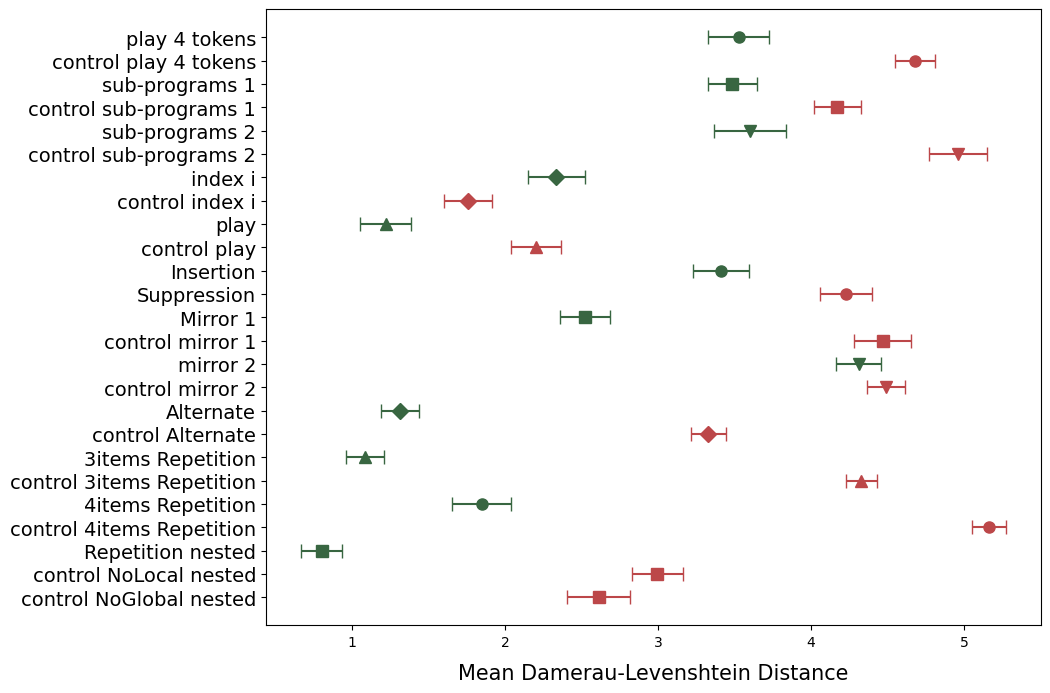

In [29]:
plot_mean_dl(data_main, plot_path,save=True)

### -- Structure

In [ ]:
#plot_mean_dl_structure(data_main,plot_path)

## Interclick Timings

In [ ]:
#plot_median_individual_interclick(data_main,plot_path)

In [ ]:
#plot_common_interclick(data_main,plot_path,expression=False,x_axis_num=False,z_score=True)
#plot_individual_interclick(df,plot_path,expression=True,x_axis_num=False,z_score=False)


# Position Error: Heatmap representation

In [ ]:
#plot_heatmap(data_main,plot_path,show=False)

# OLS Linear Regression

In [ ]:
#plot_regression(data_noTraining,plot_path)

In [ ]:
#plot_regression(data_noTraining,plot_path,dl_distance=False,complexity_measure='LoT Complexity', labels=False)

# Target responses Interclick

In [ ]:
top8(seq_name_list,df)

In [ ]:
response_structure=[0, 1, 2, 3, 3, 2, 1, 0, 0, 3, 2, 1] 
plot_targeted_interclick(df,response_structure)

# Length of responses distribution

In [ ]:
#plot_length_distribution(data_main, plot_path)
#plot_all_length(data_main,plot_path)

# Deletion Error heatmaps

In [ ]:
#plot_deletion_errors(data_main,plot_path)

---

# Supplements

In [ ]:
data_main.columns

In [ ]:
data_main[(data_main['seq_name']==seq_name_list[0])&(data_main['performance']=='fail')][['sequences_structure','comparable_temp']]

In [ ]:
specific_data=data_main[(data_main['seq_name']=="control sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==10))]
plot_specific_heatmap(specific_data,plot_path,'control_subPrograms2_lengthOf10')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="control sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==9))]
plot_specific_heatmap(specific_data,plot_path,'control_subPrograms2_lengthOf9')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==12))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf12')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==11))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf11')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==10))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf10')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==9))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf9')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==8))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf8')

In [ ]:
specific_data=data_main[(data_main['seq_name']=="sub-programs 2")&(data_main['comparable_temp'].apply(lambda x: len(x)==7))]
plot_specific_heatmap(specific_data,plot_path,'subPrograms2_lengthOf7')

In [ ]:
seq_name=[i for i in data_main['seq_name'].unique()]

In [ ]:
data_main.head()

In [ ]:
data_main[(data_main['seq_name']==seq_name[-5])&(data_main['performance']=='fail')][['seq','sequences_response','comparable_temp']]

In [ ]:
len(data_main[(data_main['seq_name']==seq_name[-5])&(data_main['comparable_temp'].apply(lambda x:x==[0, 1, 2, 0, 1, 2, 0, 1, 2]))]['sequences_response'])


In [ ]:
type(data_main.at[1,'comparable_temp'])